# (노트) Fashion_MNIST (2)

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [데이터과학]

## imports 

In [1]:
import tensorflow as tf 
import tensorflow.experimental.numpy as tnp

In [2]:
tnp.experimental_enable_numpy_behavior()

In [47]:
import matplotlib.pyplot as plt

## 올바른 데이터 정리

`-` fashion mnist data 다시 불러오자 

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [45]:
x_train.shape

(60000, 28, 28)

- 이미지는 원래 가로픽셀 * 세로픽셀 * 3 이어야 한다. (색을 표현하는 basis는 빨,녹,파)

`-` 따라서 이미지의 차원이 단지 (28,28)이라는 것은 흑백이미지라는 뜻이다. 

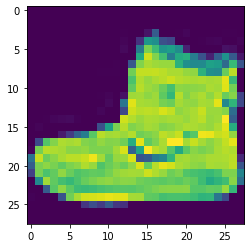

In [49]:
plt.imshow(x_train[0]) 

- 아닌데요?! 칼라인데요?! -> 흑백이다. 그냥 밝을수록 노란색, 어두울수록 남색으로 표현한것 뿐임 (colormap이 viridis일 뿐임)

`-` 일반적으로 분석할 이미지는 칼라를 의미하는 채널도 포함할테니 아래와 같이 자료형을 정리하는게 일반적으로 이미지 자료를 분석하는 정석적인 처리방법이다. 

In [4]:
X = tf.constant(x_train.reshape(-1,28,28,1),dtype=tf.float64)
y = tf.keras.utils.to_categorical(y_train)
XX = tf.constant(x_test.reshape(-1,28,28,1),dtype=tf.float64)
yy = tf.keras.utils.to_categorical(y_test)

2022-05-09 12:54:30.588799: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:939] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [50]:
X.shape, XX.shape

(TensorShape([60000, 28, 28, 1]), TensorShape([10000, 28, 28, 1]))

- keras에서 이미지자료는 (관측치수,픽셀,픽셀,채널)과 같은 형식을 가진다. 
- 예를들어 256*256 size인 칼라이미지(채널수=3)가 10개 있다면 X.shape은 (10,256,256,3)이다. 

## 올바른 데이터일경우 DNN 쓰기 

### (예제1) X -> Dense(30,relu) -> Dense(10,softmax):=> y 

`-` 이러한 아키텍처를 돌리기 위해서는 X의 shape을 미리 바꿔야 했었다. 혹시 바꾸지 않는 방법도 있을까? 

`-` tf.keras.layers.Flatten()

In [52]:
flttn = tf.keras.layers.Flatten()

In [53]:
flttn

- type: flatten <- 머 어쩌란거야..

In [54]:
set(dir(flttn)) & {'__call__'}

{'__call__'}

- call이 있음 -> 써보자

In [55]:
X.shape

TensorShape([60000, 28, 28, 1])

In [56]:
flttn(X) # 오..? 

<tf.Tensor: shape=(60000, 784), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

펴진다? 즉 X.reshape(-1,784)와 같은 기능!

`-` 근데 이거 레이어다? 즉 네트워크에 add 할 수 있다는 의미!

`-` 그렇다면 아래와 같이 예제를 풀어도 괜찮겠다.

In [10]:
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(30,activation='relu'))
net1.add(tf.keras.layers.Dense(10,activation='softmax'))
net1.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net1.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 648us/step - loss: 2.4901 - accuracy: 0.3301
Epoch 2/5
1875/1875 [==============================] - 1s 655us/step - loss: 1.3295 - accuracy: 0.4670
Epoch 3/5
1875/1875 [==============================] - 1s 660us/step - loss: 1.0513 - accuracy: 0.5921
Epoch 4/5
1875/1875 [==============================] - 1s 670us/step - loss: 0.8078 - accuracy: 0.6848
Epoch 5/5
1875/1875 [==============================] - 1s 649us/step - loss: 0.7067 - accuracy: 0.7244


`-` 관찰

In [57]:
net1.layers

In [59]:
net1.layers[0](X) # 레이어를 통과하는 순간 전처리!

<tf.Tensor: shape=(60000, 784), dtype=float32, numpy=
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)>

In [62]:
net1.layers[1](net1.layers[0](X)) # 출력이 30이니까~ + 렐루를 거쳐서 0또는 양수인 모습!

<tf.Tensor: shape=(60000, 30), dtype=float32, numpy=
array([[  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   0.       ],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   0.       ],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   5.6004076],
       ...,
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       , 479.17157  ],
       [  0.       ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   0.       ],
       [ 39.075447 ,   0.       ,   0.       , ...,   0.       ,
          0.       ,   0.       ]], dtype=float32)>

In [65]:
net1.layers[2](net1.layers[1](net1.layers[0](X))) # 최종출력 10차원, 각각은 확률을 의미하게 된다. 

<tf.Tensor: shape=(60000, 10), dtype=float32, numpy=
array([[0.0000000e+00, 1.3088903e-31, 4.1219791e-35, ..., 1.0877927e-03,
        3.0683451e-17, 9.9822003e-01],
       [5.8229882e-01, 1.2348780e-02, 4.6196397e-02, ..., 2.7323686e-02,
        2.9729774e-02, 5.3795548e-03],
       [1.9773273e-01, 2.7041491e-02, 1.6853711e-01, ..., 6.4152046e-14,
        1.3129631e-02, 4.5654854e-16],
       ...,
       [3.9076394e-06, 2.3412628e-02, 9.3482089e-10, ..., 0.0000000e+00,
        2.5920444e-03, 0.0000000e+00],
       [2.2144917e-01, 2.3952849e-02, 1.7827164e-01, ..., 1.6169031e-12,
        1.3061395e-02, 5.8266939e-15],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 2.4974506e-10,
        2.1434335e-08, 0.0000000e+00]], dtype=float32)>

`-` (참고) metrics=['accuracy'] 대신에 이렇게 해도된다~

In [66]:
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(30,activation='relu'))
net1.add(tf.keras.layers.Dense(10,activation='softmax'))
net1.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=[tf.metrics.CategoricalAccuracy()])
net1.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 1s 659us/step - loss: 2.2289 - categorical_accuracy: 0.4215
Epoch 2/5
1875/1875 [==============================] - 1s 654us/step - loss: 1.2379 - categorical_accuracy: 0.5035
Epoch 3/5
1875/1875 [==============================] - 1s 668us/step - loss: 0.9116 - categorical_accuracy: 0.6514
Epoch 4/5
1875/1875 [==============================] - 1s 646us/step - loss: 0.7402 - categorical_accuracy: 0.7165
Epoch 5/5
1875/1875 [==============================] - 1s 658us/step - loss: 0.7005 - categorical_accuracy: 0.7261


In [67]:
id(tf.metrics.CategoricalAccuracy), id(tf.keras.metrics.CategoricalAccuracy)

(94190997032800, 94190997032800)

- 주소가 똑같네요, 이게 무슨말인지 알죠?

`-` 주의사항: tf.metrics.Accuracy() 말고 tf.metrics.CategoricalAccuracy() 를 써야함

`-` (참고2) 메트릭을 추가할수도 있다 

In [68]:
net1 = tf.keras.Sequential()
net1.add(tf.keras.layers.Flatten())
net1.add(tf.keras.layers.Dense(30,activation='relu'))
net1.add(tf.keras.layers.Dense(10,activation='softmax'))
net1.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=[tf.metrics.CategoricalAccuracy(),tf.metrics.Recall()])
net1.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 912us/step - loss: 2.2265 - categorical_accuracy: 0.5102 - recall_1: 0.3780
Epoch 2/5
1875/1875 [==============================] - 2s 914us/step - loss: 0.9666 - categorical_accuracy: 0.6313 - recall_1: 0.4881
Epoch 3/5
1875/1875 [==============================] - 2s 933us/step - loss: 0.8222 - categorical_accuracy: 0.6703 - recall_1: 0.5211
Epoch 4/5
1875/1875 [==============================] - 2s 896us/step - loss: 0.7258 - categorical_accuracy: 0.7119 - recall_1: 0.5875
Epoch 5/5
1875/1875 [==============================] - 2s 908us/step - loss: 0.6747 - categorical_accuracy: 0.7314 - recall_1: 0.6133


`-` 리콜을 추가하면 test set의 성능평가에도 리콜을 볼 수 있다.

In [69]:
net1.evaluate(XX,yy)

313/313 [==============================] - 0s 889us/step - loss: 0.7913 - categorical_accuracy: 0.6781 - recall_1: 0.5622


[0.7913308143615723, 0.6780999898910522, 0.5622000098228455]

### (예제2) X -> Dense(500,relu) -> Dense(500,relu) -> Dense(10,softmax):=>y 

`-` 다른모형으로도 적합시켜보자. 

In [72]:
net2 = tf.keras.Sequential()
net2.add(tf.keras.layers.Flatten())
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(10,activation='softmax'))
net2.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net2.fit(X,y,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 2s 730us/step - loss: 2.3280 - accuracy: 0.7528
Epoch 2/5
1875/1875 [==============================] - 1s 726us/step - loss: 0.6350 - accuracy: 0.7957
Epoch 3/5
1875/1875 [==============================] - 1s 741us/step - loss: 0.5479 - accuracy: 0.8117
Epoch 4/5
1875/1875 [==============================] - 1s 705us/step - loss: 0.4756 - accuracy: 0.8331
Epoch 5/5
1875/1875 [==============================] - 1s 703us/step - loss: 0.4553 - accuracy: 0.8389


In [71]:
net2.fit(XX,yy)

313/313 [==============================] - 0s 1ms/step - loss: 0.4712 - categorical_accuracy: 0.8307


`-` 좀 더 돌려보자. 

In [76]:
net2 = tf.keras.Sequential()
net2.add(tf.keras.layers.Flatten())
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(500,activation='relu'))
net2.add(tf.keras.layers.Dense(10,activation='softmax'))
net2.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net2.fit(X,y,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 2s 782us/step - loss: 2.4445 - accuracy: 0.7592
Epoch 2/10
1875/1875 [==============================] - 1s 757us/step - loss: 0.5705 - accuracy: 0.8079
Epoch 3/10
1875/1875 [==============================] - 1s 747us/step - loss: 0.4640 - accuracy: 0.8344
Epoch 4/10
1875/1875 [==============================] - 1s 758us/step - loss: 0.4230 - accuracy: 0.8470
Epoch 5/10
1875/1875 [==============================] - 1s 737us/step - loss: 0.4083 - accuracy: 0.8539
Epoch 6/10
1875/1875 [==============================] - 1s 776us/step - loss: 0.3965 - accuracy: 0.8576
Epoch 7/10
1875/1875 [==============================] - 1s 757us/step - loss: 0.3827 - accuracy: 0.8648
Epoch 8/10
1875/1875 [==============================] - 1s 777us/step - loss: 0.3703 - accuracy: 0.8691
Epoch 9/10
1875/1875 [==============================] - 1s 739us/step - loss: 0.3734 - accuracy: 0.8685
Epoch 10/10
1875/1875 [==============================] - 1s 757u

In [74]:
net2.fit(XX,yy)

313/313 [==============================] - 0s 1ms/step - loss: 0.4653 - accuracy: 0.8372


`-` 이 이상은 비효율적인듯.. 

### 더 좋은 모형을 만들고 싶은데.. 

#### 아주 복잡한 DNN

`-` 무지성: 아 몰라 딥러닝이 해주겠지

In [99]:
net3 = tf.keras.Sequential()
net3.add(tf.keras.layers.Flatten())
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(500,activation='relu'))
net3.add(tf.keras.layers.Dense(10,activation='softmax'))
net3.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam',metrics=['accuracy'])
net3.fit(X,y,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.8450 - accuracy: 0.7947
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4571 - accuracy: 0.8374
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.4110 - accuracy: 0.8547
Epoch 4/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3971 - accuracy: 0.8599
Epoch 5/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3827 - accuracy: 0.8664
Epoch 6/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3690 - accuracy: 0.8717
Epoch 7/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3455 - accuracy: 0.8779
Epoch 8/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3522 - accuracy: 0.8789
Epoch 9/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3258 - accuracy: 0.8844
Epoch 10/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.323

In [78]:
net3.evaluate(XX,yy)

313/313 [==============================] - 0s 893us/step - loss: 0.3992 - accuracy: 0.8607


[0.399242103099823, 0.8607000112533569]

In [79]:
net2.summary()

Model: "sequential_12"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_14 (Flatten)        (32, 784)                 0         
                                                                 
 dense_32 (Dense)            (32, 500)                 392500    
                                                                 
 dense_33 (Dense)            (32, 500)                 250500    
                                                                 
 dense_34 (Dense)            (32, 10)                  5010      
                                                                 
Total params: 648,010
Trainable params: 648,010
Non-trainable params: 0
_________________________________________________________________


In [80]:
net3.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_15 (Flatten)        (None, 784)               0         
                                                                 
 dense_35 (Dense)            (None, 500)               392500    
                                                                 
 dense_36 (Dense)            (None, 500)               250500    
                                                                 
 dense_37 (Dense)            (None, 500)               250500    
                                                                 
 dense_38 (Dense)            (None, 500)               250500    
                                                                 
 dense_39 (Dense)            (None, 500)               250500    
                                                                 
 dense_40 (Dense)            (None, 10)              

`-` 파라메터 증가대비 그닥.. 

`-` 왠지 DNN계열로는 한계가 있어보인다. 

#### 발상의 전환 

`-` Flattne 레이어를 보면서 느낀점: 생각해보니까 $X \to \hat{y}$를 만드는 과정이 꼭 Full Linear Transform(Dense layer) + Activation(Activation layer)일 필요는 없잖아?  

`-` 뭐가있지? 

In [19]:
dir(tf.keras.layers)

['AbstractRNNCell',
 'Activation',
 'ActivityRegularization',
 'Add',
 'AdditiveAttention',
 'AlphaDropout',
 'Attention',
 'Average',
 'AveragePooling1D',
 'AveragePooling2D',
 'AveragePooling3D',
 'AvgPool1D',
 'AvgPool2D',
 'AvgPool3D',
 'BatchNormalization',
 'Bidirectional',
 'CategoryEncoding',
 'CenterCrop',
 'Concatenate',
 'Conv1D',
 'Conv1DTranspose',
 'Conv2D',
 'Conv2DTranspose',
 'Conv3D',
 'Conv3DTranspose',
 'ConvLSTM1D',
 'ConvLSTM2D',
 'ConvLSTM3D',
 'Convolution1D',
 'Convolution1DTranspose',
 'Convolution2D',
 'Convolution2DTranspose',
 'Convolution3D',
 'Convolution3DTranspose',
 'Cropping1D',
 'Cropping2D',
 'Cropping3D',
 'Dense',
 'DenseFeatures',
 'DepthwiseConv1D',
 'DepthwiseConv2D',
 'Discretization',
 'Dot',
 'Dropout',
 'ELU',
 'Embedding',
 'Flatten',
 'GRU',
 'GRUCell',
 'GaussianDropout',
 'GaussianNoise',
 'GlobalAveragePooling1D',
 'GlobalAveragePooling2D',
 'GlobalAveragePooling3D',
 'GlobalAvgPool1D',
 'GlobalAvgPool2D',
 'GlobalAvgPool3D',
 'GlobalM

`-` 엄청많아.. 

`-` 우리는 이중에서 2D conv, max pooling 에 관심이 있다! (이번수업은 max pooling 정도만)

#### MaxPooling2D, MaxPool2D

In [81]:
id(tf.keras.layers.MaxPooling2D), id(tf.keras.layers.MaxPool2D)

(94190996101664, 94190996101664)

`-` 테스트1: (2,2) 이미지

In [82]:
mp = tf.keras.layers.MaxPool2D() # pool size의 디폴트는 (2,2)

In [83]:
XXX = tnp.arange(1*2*2*1).reshape(1,2,2,1)
XXX

<tf.Tensor: shape=(1, 2, 2, 1), dtype=int64, numpy=
array([[[[0],
         [1]],

        [[2],
         [3]]]])>

In [84]:
XXX.reshape(1,2,2) # 채널때문에 살짝 헷갈리지만 실제로는 이렇게 생긴 이미지! 

<tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
array([[[0, 1],
        [2, 3]]])>

In [85]:
mp(XXX)

<tf.Tensor: shape=(1, 1, 1, 1), dtype=int64, numpy=array([[[[3]]]])>

`-` 테스트2: (4,4) 이미지로 변경

In [86]:
mp = tf.keras.layers.MaxPool2D() # pool size의 디폴트는 (2,2)

In [87]:
XXX = tnp.arange(1*4*4*1).reshape(1,4,4,1)
XXX,XXX.reshape(1,4,4)

(<tf.Tensor: shape=(1, 4, 4, 1), dtype=int64, numpy=
 array([[[[ 0],
          [ 1],
          [ 2],
          [ 3]],
 
         [[ 4],
          [ 5],
          [ 6],
          [ 7]],
 
         [[ 8],
          [ 9],
          [10],
          [11]],
 
         [[12],
          [13],
          [14],
          [15]]]])>,
 <tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11],
         [12, 13, 14, 15]]])>)

In [88]:
mp(XXX),mp(XXX).reshape(1,2,2)

(<tf.Tensor: shape=(1, 2, 2, 1), dtype=int64, numpy=
 array([[[[ 5],
          [ 7]],
 
         [[13],
          [15]]]])>,
 <tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[ 5,  7],
         [13, 15]]])>)

`-` 테스트3: (6,6) 이미지, size변경

In [89]:
XXX = tnp.arange(1*6*6*1).reshape(1,6,6,1)
XXX.reshape(1,6,6)

<tf.Tensor: shape=(1, 6, 6), dtype=int64, numpy=
array([[[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29],
        [30, 31, 32, 33, 34, 35]]])>

In [90]:
mp(XXX).reshape(1,3,3) # 왜 (2,2)씩...? 

<tf.Tensor: shape=(1, 3, 3), dtype=int64, numpy=
array([[[ 7,  9, 11],
        [19, 21, 23],
        [31, 33, 35]]])>

In [91]:
mp3 = tf.keras.layers.MaxPool2D((3,3))
mp3(XXX).reshape(1,2,2)

<tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
array([[[14, 17],
        [32, 35]]])>

`-` 테스트4: 관측치증가

In [31]:
XXX = tnp.arange(2*4*4*1).reshape(2,4,4,1)
XXX.reshape(2,4,4)

<tf.Tensor: shape=(2, 4, 4), dtype=int64, numpy=
array([[[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11],
        [12, 13, 14, 15]],

       [[16, 17, 18, 19],
        [20, 21, 22, 23],
        [24, 25, 26, 27],
        [28, 29, 30, 31]]])>

In [32]:
mp(XXX).reshape(2,2,2)

<tf.Tensor: shape=(2, 2, 2), dtype=int64, numpy=
array([[[ 5,  7],
        [13, 15]],

       [[21, 23],
        [29, 31]]])>

`-` 테스트5: 채널증가

In [33]:
XXX = tnp.arange(1*4*4*3).reshape(1,4,4,3)
XXX

<tf.Tensor: shape=(1, 4, 4, 3), dtype=int64, numpy=
array([[[[ 0,  1,  2],
         [ 3,  4,  5],
         [ 6,  7,  8],
         [ 9, 10, 11]],

        [[12, 13, 14],
         [15, 16, 17],
         [18, 19, 20],
         [21, 22, 23]],

        [[24, 25, 26],
         [27, 28, 29],
         [30, 31, 32],
         [33, 34, 35]],

        [[36, 37, 38],
         [39, 40, 41],
         [42, 43, 44],
         [45, 46, 47]]]])>

In [34]:
XXX1 = XXX[...,0]
XXX2 = XXX[...,1]
XXX3 = XXX[...,2]
XXX1,XXX2,XXX3

(<tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 0,  3,  6,  9],
         [12, 15, 18, 21],
         [24, 27, 30, 33],
         [36, 39, 42, 45]]])>,
 <tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 1,  4,  7, 10],
         [13, 16, 19, 22],
         [25, 28, 31, 34],
         [37, 40, 43, 46]]])>,
 <tf.Tensor: shape=(1, 4, 4), dtype=int64, numpy=
 array([[[ 2,  5,  8, 11],
         [14, 17, 20, 23],
         [26, 29, 32, 35],
         [38, 41, 44, 47]]])>)

In [35]:
YYY1 = mp(XXX)[...,0]
YYY2 = mp(XXX)[...,1]
YYY3 = mp(XXX)[...,2]

In [36]:
YYY1,YYY2,YYY3

(<tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[15, 21],
         [39, 45]]])>,
 <tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[16, 22],
         [40, 46]]])>,
 <tf.Tensor: shape=(1, 2, 2), dtype=int64, numpy=
 array([[[17, 23],
         [41, 47]]])>)

`-` 관측치와 채널은 처음에만 따져보고 외울때는 1observation/흑백 버전만 고려해도 무방! (나머지는 복붙이니까)

#### tf.keras.layers.Convolution2D (skip)

`-` 이것도 뭐 있음

`-` 나중에 할건데 이거 선형변환임

### (예제3) CNN 모형

In [102]:
tf.random.set_seed(43052)
net4 = tf.keras.Sequential()
net4.add(tf.keras.layers.Convolution2D(30,(5,5),activation='relu'))
net4.add(tf.keras.layers.MaxPool2D()) # 디폴트가 (2,2)라서 생략가능
net4.add(tf.keras.layers.Convolution2D(30,(5,5),activation='relu'))
net4.add(tf.keras.layers.MaxPool2D()) # 디폴트가 (2,2)라서 생략가능
net4.add(tf.keras.layers.Flatten())
net4.add(tf.keras.layers.Dense(10,activation='softmax'))
net4.compile(loss=tf.losses.categorical_crossentropy, optimizer='adam', metrics=['accuracy'])

> tf.keras.layers.MaxPool2D() 은 tf.keras.layers.MaxPool2D(pool_size=(3,3))  와 같다. 

In [103]:
net4.fit(X,y,epochs=10)

Epoch 1/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.7929 - accuracy: 0.7906
Epoch 2/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3962 - accuracy: 0.8597
Epoch 3/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3604 - accuracy: 0.8716
Epoch 4/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3412 - accuracy: 0.8779
Epoch 5/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3263 - accuracy: 0.8813
Epoch 6/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3167 - accuracy: 0.8853
Epoch 7/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.3051 - accuracy: 0.8885
Epoch 8/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2964 - accuracy: 0.8928
Epoch 9/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.2926 - accuracy: 0.8919
Epoch 10/10
1875/1875 [==============================] - 2s 1ms/step - loss: 0.283

In [104]:
net4.evaluate(XX,yy) ## DNN의 한계를 너무 가볍게 돌파하는 모습

313/313 [==============================] - 0s 835us/step - loss: 0.3542 - accuracy: 0.8782


[0.35420483350753784, 0.8781999945640564]

In [105]:
net4.summary() ## 파라메터수 엄청 적음 

Model: "sequential_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 24, 24, 30)        780       
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 12, 12, 30)       0         
 g2D)                                                            
                                                                 
 conv2d_7 (Conv2D)           (None, 8, 8, 30)          22530     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 4, 4, 30)         0         
 g2D)                                                            
                                                                 
 flatten_19 (Flatten)        (None, 480)               0         
                                                                 
 dense_49 (Dense)            (None, 10)              

In [106]:
28120 / 1399510 

0.02009274674707576

- net3대비 2퍼센트의 파라메터만 사용

`-` 아키텍처의 변화 추적

In [41]:
net4.layers

In [107]:
c1,m1,c2,m2,flttn,d1 = net4.layers

In [108]:
print(X.shape)
print(c1(X).shape)
print(m1(c1(X)).shape)
print(c2(m1(c1(X))).shape)
print(m2(c2(m1(c1(X)))).shape)
print(flttn(m2(c2(m1(c1(X))))).shape)
print(d1(flttn(m2(c2(m1(c1(X)))))).shape)

(60000, 28, 28, 1)
(60000, 24, 24, 30)
(60000, 12, 12, 30)
(60000, 8, 8, 30)
(60000, 4, 4, 30)
(60000, 480)
(60000, 10)
